# 23 — Sochi field data forward modelling with IBM topography

Real-data test of the IBM acoustic topography solver using a near-surface
velocity model from the Sochi field site.  The model is resampled to a
uniform 0.3 m grid to satisfy the dispersion stability criterion
($\Delta x \le v_{\min} / 10 f_{\max} \approx 0.3$ m).

A real extracted wavelet (lowpass-filtered at 77 Hz) is injected at the
source position, and the synthetic seismogram is compared with the
observed data.

In [1]:
from PVGeo.grids import SurferGridReader
import numpy as np
from matplotlib import pyplot as plt
import segyio
from examples.seismic.fwi.seg_util import get_headers, get_source_dict
from examples.seismic.fwi.zond_util import read_zond
from examples.seismic.fwi.paths import *

In [2]:
dem = SurferGridReader().apply(GRID)

In [3]:
vp = dem.active_scalars

# Reshape to 2D grid (rows, cols)
n_rows = dem.dimensions[1]  # 259
n_cols = dem.dimensions[0]  # 443
shape = dem.dimensions[:-1]
spacing = dem.spacing[:-1]
origin = dem.bounds[0], -dem.bounds[3]
erigin = dem.bounds[1], -dem.bounds[2]
vp_2d = np.flip(vp.reshape(n_rows, n_cols), axis=0).T
x_vp, z_vp = [np.linspace(ori, eri, num=n) for ori, eri, n in zip(origin, erigin, shape)]
print(dem)

ImageData (0x7bd998ef2f20)
  N Cells:      568632
  N Points:     570251
  X Bounds:     0.000e+00, 1.102e+03
  Y Bounds:     -3.640e+02, 1.520e+02
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   1103, 517, 1
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1


In [4]:
header_list = [
    segyio.TraceField.SourceX,
    segyio.TraceField.SourceY,
    segyio.TraceField.SourceSurfaceElevation ,
    segyio.TraceField.GroupX,
    segyio.TraceField.GroupY,
    segyio.TraceField.ReceiverGroupElevation ,
    segyio.TraceField.SourceGroupScalar,
    segyio.TraceField.ElevationScalar
]

remap_string = "pick1,4R,IBM,181 / pick2,4R,IBM,185 / rec_sloc,4R,IBM,197 / sou_sloc,4R,IBM,201"

with segyio.open(DATA_0, "r", ignore_geometry=True) as f:
    data = segyio.tools.collect(f.trace[:])
    hdr = get_headers(f, header_list, remap_string)
    data_dt = segyio.tools.dt(f)
for key in ['SourceX', 'SourceY', 'SourceSurfaceElevation', 'GroupX','GroupY', 'ReceiverGroupElevation']:
    hdr[key] = hdr[key] / 100

with segyio.open(WAVELETS, "r", ignore_geometry=True) as f:
    data_wavelets = segyio.tools.collect(f.trace[:])
    wavelets_dt = segyio.tools.dt(f)

In [5]:
zond_data, geocoord, topo = read_zond(ZOND_RES)

In [6]:
buff = get_source_dict(15, data, hdr, data_wavelets, zond_data)
print(buff)

{'sou_x': np.float64(553140.15), 'sou_z': np.float64(-57.55), 'data': array([[ 0.00000000e+00,  2.09874474e-04,  3.31523450e-04, ...,
        -1.20004574e-02, -1.46226715e-02, -1.82716548e-02],
       [-0.00000000e+00, -1.10668698e-04, -4.09572240e-05, ...,
         4.09276932e-02,  4.31265235e-02,  4.62040715e-02],
       [ 0.00000000e+00, -1.11544530e-07, -1.02140199e-04, ...,
        -6.90101609e-02, -7.83880576e-02, -8.49168599e-02],
       ...,
       [ 0.00000000e+00,  1.87080033e-04,  2.68521289e-05, ...,
         5.80472033e-03,  2.66874628e-03, -1.05714949e-03],
       [ 0.00000000e+00,  9.40386235e-06,  7.34872901e-06, ...,
        -4.40662261e-04, -2.60870758e-04,  3.96245485e-03],
       [-0.00000000e+00, -1.78124770e-04, -5.64563015e-05, ...,
        -2.00071023e-03, -6.55102194e-04, -1.66423721e-04]],
      shape=(108, 550), dtype=float32), 'rec_x': array([  10.289,   20.314,   30.33 ,   40.434,   50.456,   60.279,
         70.251,   80.234,   90.357,  100.373,  110.309, 

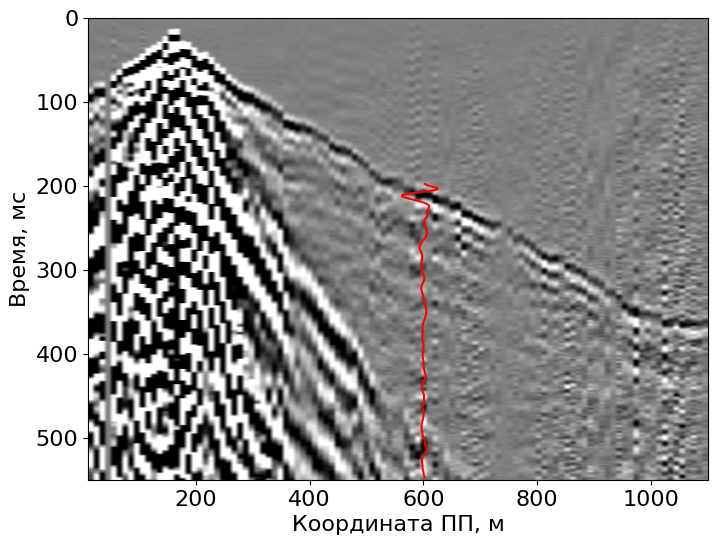

In [7]:
seismogram = buff['data']
rec_x = buff['rec_x']
rec_z = buff['rec_z']

wavelet = buff['wavelet'][:350]
x_wavelet = 600.
amp_wavelet = 25.
wavelet_norm = wavelet/np.amax(wavelet)
wavelet_plot = x_wavelet + wavelet_norm * amp_wavelet
qa = np.quantile(seismogram, 0.9)
plt.imshow(seismogram.T, cmap='grey', vmin=-qa, vmax=qa, extent=[rec_x[0], rec_x[-1], 550, 0])
plt.plot(wavelet_plot, 198+np.arange(0, wavelet.size, wavelets_dt/1e3), c='r')
plt.gca().set_aspect('auto')
plt.ylabel("Время, мс")
plt.xlabel("Координата ПП, м")
plt.show()

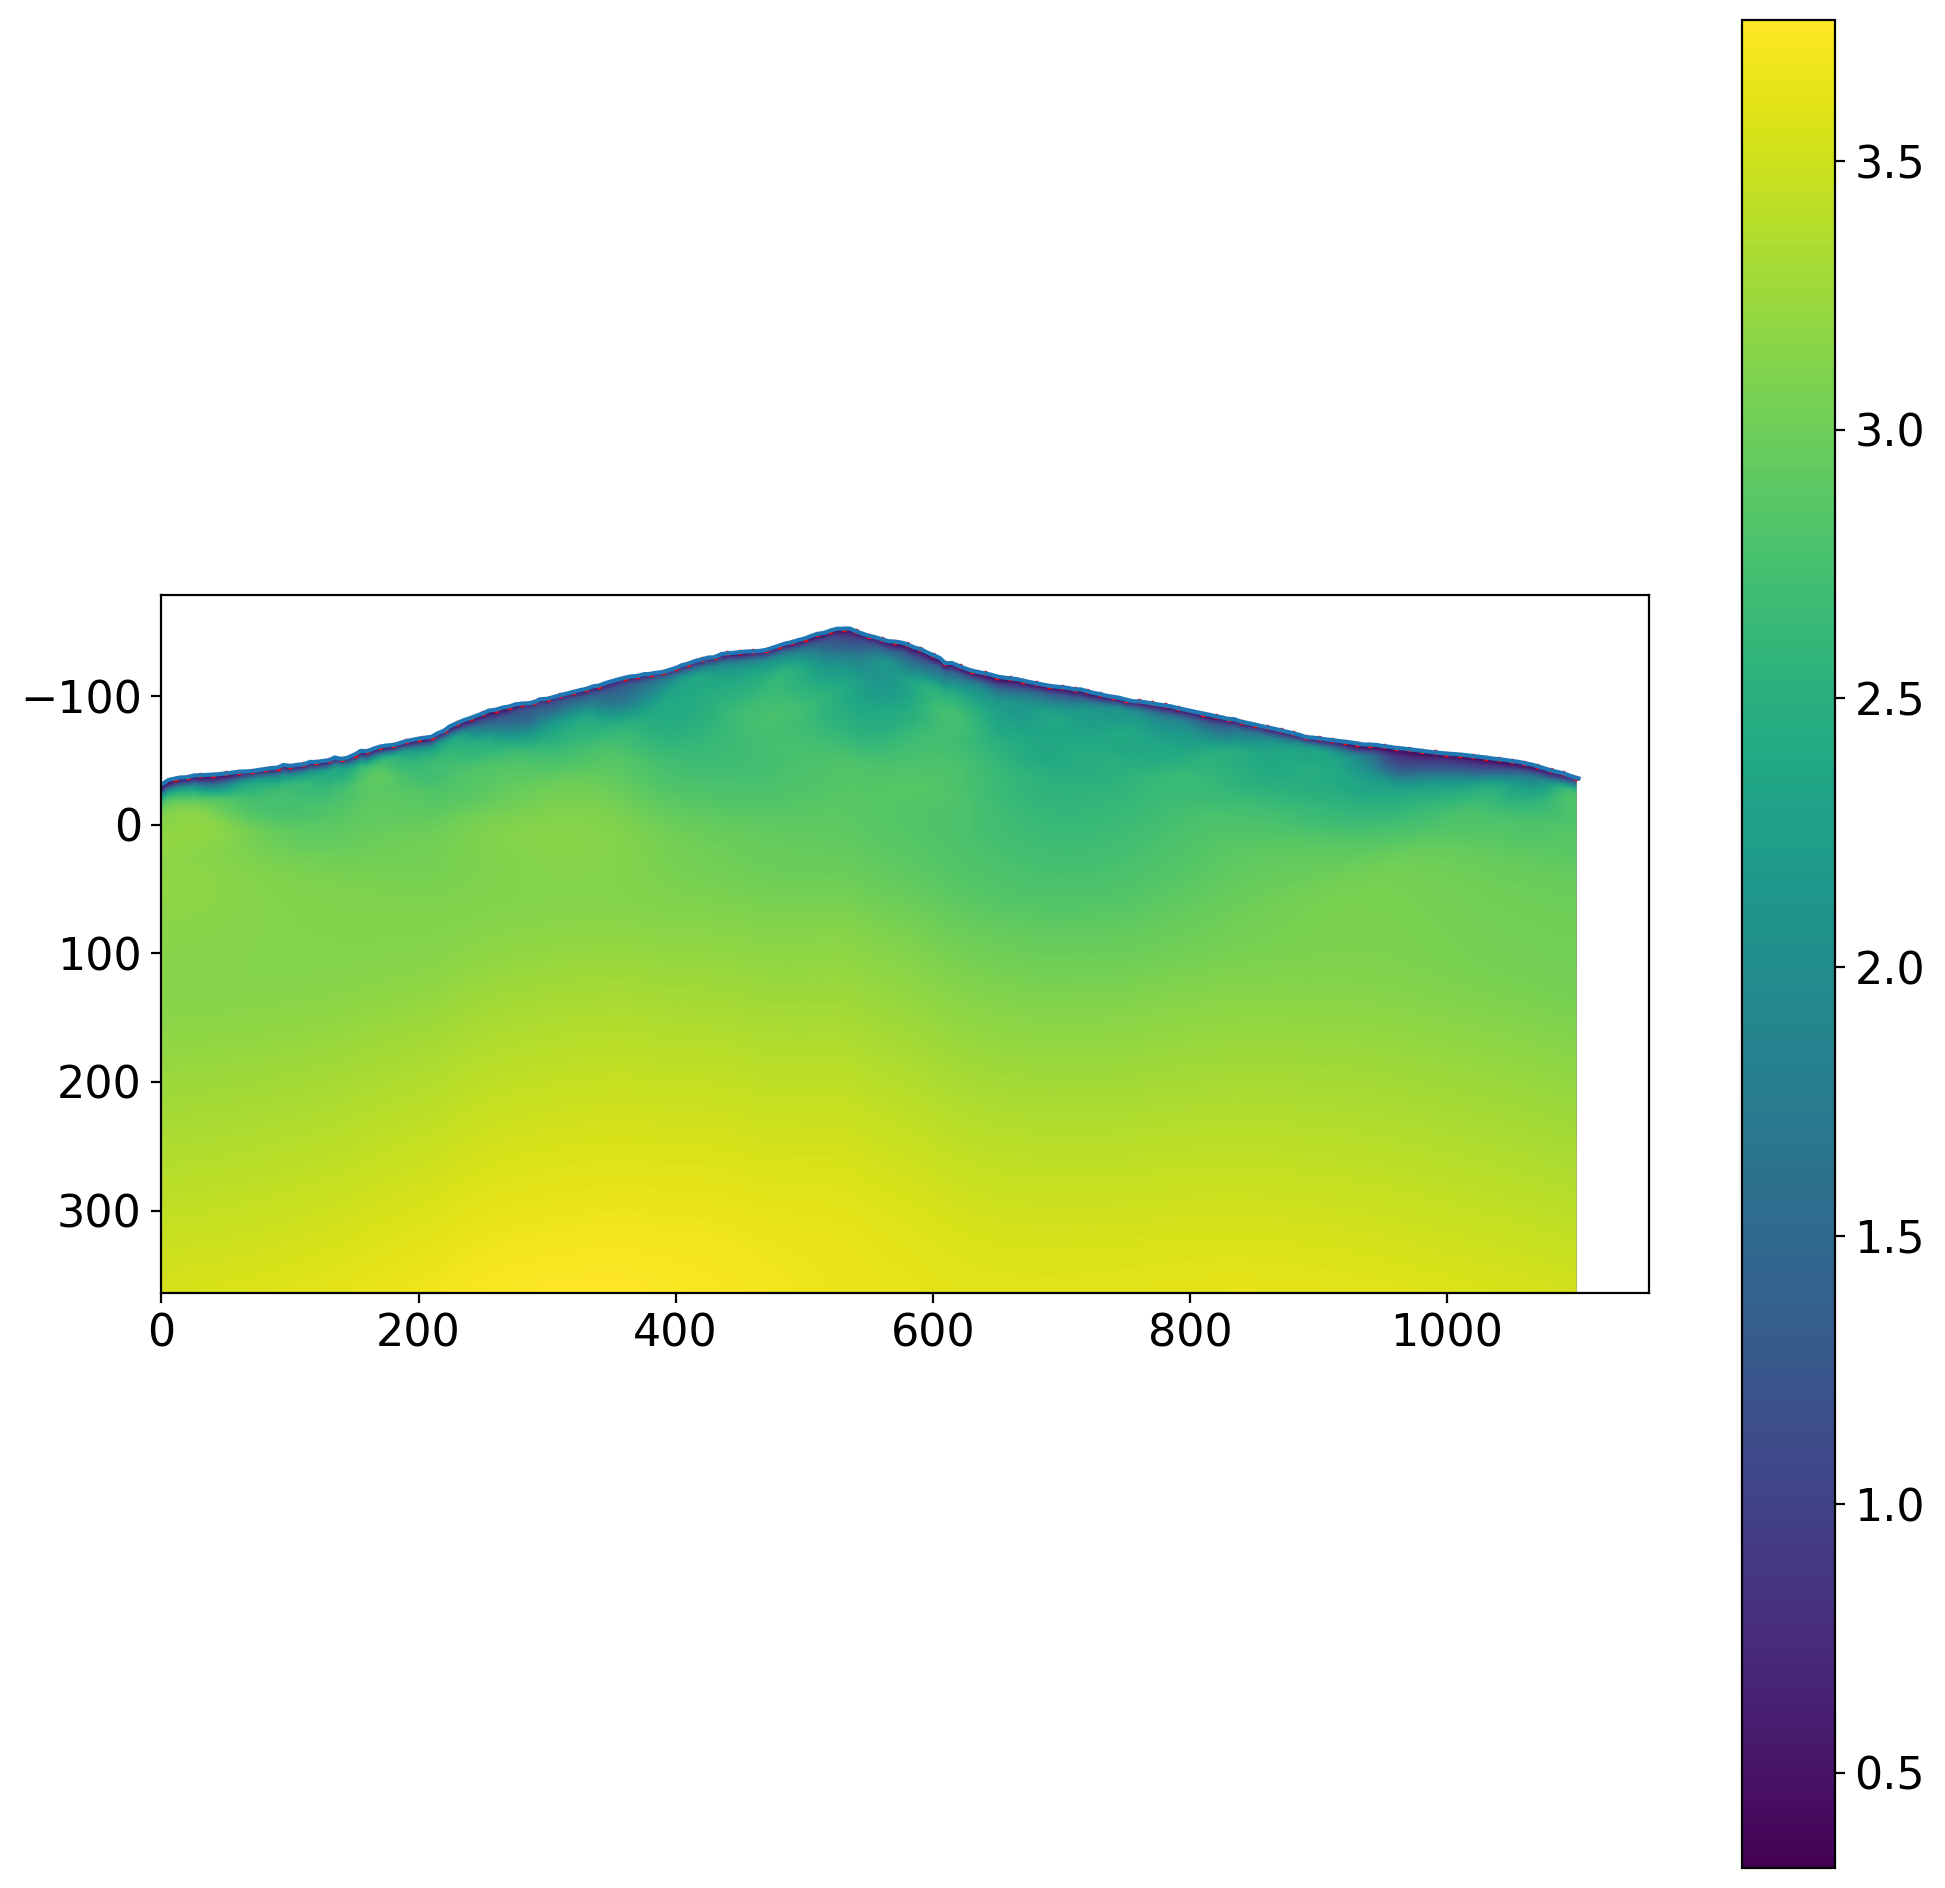

In [8]:
plt.figure(figsize=(12, 12), dpi=200)
plt.imshow(vp_2d.T, extent=[x_vp[0], x_vp[-1], z_vp[-1], z_vp[0]])
plt.colorbar()
plt.plot(topo.values[:, 0], -topo.values[:, 1])
plt.scatter(rec_x, rec_z, c='r', s=1)
plt.gca().set_aspect('equal')
plt.show()

## 1. Model preparation — resample to 0.3 m grid

The DEM has 1 m native spacing.  We resample to 0.3 m to avoid numerical
dispersion at $f_{\max}=100$ Hz in the slowest region ($v_{\min}\approx 300$ m/s).

In [9]:
# NBVAL_IGNORE_OUTPUT
dx = dz = 0.3

from scipy.interpolate import RegularGridInterpolator

# Domain extent from DEM bounds (X: 0-1102, Y: -364 to 152 => z: -152 to 364)
x0, x1 = 0., 1102.
z0, z1 = -152., 364.
nx = int(np.ceil((x1 - x0) / dx))   # 3674
nz = int(np.ceil((z1 - z0) / dz))   # 1720

x_new = np.linspace(x0, x0 + nx * dx, nx)
z_new = np.linspace(z0, z0 + nz * dz, nz)

# Build interpolator from the DEM grid (z_old reversed because DEM flips y)
x_old = np.linspace(x0, x1, 1103)
z_old = np.linspace(z0, z1, 517)

interp = RegularGridInterpolator(
    (x_old, z_old), vp_2d,
    bounds_error=False, fill_value=np.nan)

X_new, Z_new = np.meshgrid(x_new, z_new, indexing='ij')
v_fine = interp((X_new, Z_new)).astype(np.float32)

print(f"Fine grid: {nx} × {nz} cells  ({nx*nz/1e6:.1f}M)")
print(f"Domain: {x1-x0:.0f} × {z1-z0:.0f} m")

Fine grid: 3674 × 1720 cells  (6.3M)
Domain: 1102 × 516 m


In [10]:
# NBVAL_IGNORE_OUTPUT
# Topography = first non-NaN z per x-column
topo = np.full(nx, np.nan, dtype=np.float64)
for i in range(nx):
    col = v_fine[i, :]
    valid = np.where(~np.isnan(col))[0]
    if len(valid) > 0:
        topo[i] = z_new[valid[0]]

# Fill any remaining NaNs via interpolation
mask = np.isnan(topo)
if mask.any():
    topo[mask] = np.interp(x_new[mask], x_new[~mask], topo[~mask])

print(f"Surface min/max: {topo.min():.1f} / {topo.max():.1f} m")

Surface min/max: -152.0 / -30.7 m


In [11]:
# NBVAL_IGNORE_OUTPUT
from examples.seismic.acoustic_topo.model import ModelTopo

v_fine[np.isnan(v_fine)] = np.nanmin(v_fine)
rho = np.ones_like(v_fine)

model = ModelTopo(
    origin=(x0, z0), spacing=(dx, dz), shape=(nx, nz),
    space_order=4, v=v_fine, rho=rho, topo=topo,
    nbl=20, bcs='mask')

print(f"Grid      : {nx} × {nz}  |  {dx} m spacing")
print(f"Ghost pts : {len(model.ghost_coords)}")
print(f"Critical Δt: {model.critical_dt:.4f} ms")

Operator `initdamp` ran in 0.01 s


Grid      : 3674 × 1720  |  0.3 m spacing
Ghost pts : 793520
Critical Δt: 0.0442 ms


## 2. Source and receiver geometry

Use `src_type=None` to get a zero-initialized `PointSource`, then fill with
the filtered real wavelet.

In [ ]:
# NBVAL_IGNORE_OUTPUT
from examples.seismic.utils import AcquisitionGeometry
from devito import TimeFunction

# Source position from SEGY headers
src_x = buff['sou_x']
src_z = buff['sou_z']
src_pos = np.array([[src_x, src_z]])

# Receiver positions
rec_x = buff['rec_x']
rec_z = buff['rec_z']
rec_pos = np.column_stack([rec_x, rec_z])

t0, tn = 0., 550.  # ms, matching observed record length
geom = AcquisitionGeometry(model, rec_pos, src_pos,
                           t0=t0, tn=tn, src_type=None)

# Create source once (geom.src recreates each access)
src = geom.new_src()
print(f"Source  : x={src_x:.1f}, z={src_z:.1f} m")
print(f"Receivers: {len(rec_x)}")
print(f"Time steps: {geom.nt},  dt={geom.dt:.4f} ms")

In [ ]:
# NBVAL_IGNORE_OUTPUT
from scipy.signal import butter, filtfilt
from examples.seismic.fwi.wavelets import interpolate_wavelet

# Raw wavelet from SEGY
wavelet_raw = buff['wavelet'][:350]

# Butterworth lowpass at 77 Hz, ~20 dB/octave
source_dt_us = wavelets_dt  # µs from SEGY wavelet file
fs_wav = 1e6 / source_dt_us  # Hz
Wn = 77 / (fs_wav / 2)
order = 4  # ~24 dB/octave (4th order × 6 dB/oct per pole)
b, a = butter(order, Wn, btype='low')
wavelet_filt = filtfilt(b, a, wavelet_raw)

# Interpolate to simulation dt
source_dt_ms = source_dt_us / 1000  # ms
target_dt = model.critical_dt       # ms
wavelet_sim = interpolate_wavelet(wavelet_filt, source_dt_ms, target_dt)

# Set source data (nt, npoint=1)
n_sim = len(wavelet_sim)
src.data[:n_sim, 0] = wavelet_sim.astype(np.float32)

print(f"Raw wavelet  : {len(wavelet_raw)} samples @ {source_dt_ms:.2f} ms")
print(f"Filtered     : 77 Hz lowpass, {order}th order Butterworth")


In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(wavelet_raw, alpha=0.5, label='Raw')
ax1.plot(wavelet_filt, label='Filtered (77 Hz LP)')
ax1.legend()
ax1.set_xlabel('Sample')
ax1.set_title('Wavelet before / after lowpass')

t_sim = np.arange(n_sim) * target_dt
ax2.plot(t_sim, wavelet_sim)
ax2.set_xlabel('Time (ms)')
ax2.set_title(f'Wavelet resampled to Δt={target_dt:.4f} ms')
plt.tight_layout()
plt.show()

## 3. IBM forward propagation

Run the full forward model with the IBM ghost-point correction enabled.
We use the Numba-accelerated IBM correction for speed.

In [ ]:
# NBVAL_IGNORE_OUTPUT
import time
from examples.seismic.acoustic_topo.wavesolver import AcousticTopoSolver

solver = AcousticTopoSolver(model, geom, space_order=4, use_numba=True)

t_start = time.perf_counter()
rec_synth, p_synth, summary = solver.forward(src=src, save=False)
elapsed = time.perf_counter() - t_start

syn_data = np.asarray(rec_synth.data)
print(f"Forward completed in {elapsed:.1f} s")
print(f"Synthetic data shape: {syn_data.shape}  (nt × nrec)")

In [ ]:
# NBVAL_IGNORE_OUTPUT
import matplotlib.pyplot as plt

obs_data = buff['data']  # (nt_obs, nrec)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

extent = [rec_x[0], rec_x[-1], tn, t0]

# Observed
qa_obs = np.percentile(np.abs(obs_data), 95)
axes[0].imshow(obs_data.T, cmap='gray', vmin=-qa_obs, vmax=qa_obs,
               extent=extent, aspect='auto')
axes[0].set_title('Observed')
axes[0].set_ylabel('Time (ms)')

# Synthetic
qa_syn = np.percentile(np.abs(syn_data), 95)
axes[1].imshow(syn_data.T, cmap='gray', vmin=-qa_syn, vmax=qa_syn,
               extent=extent, aspect='auto')
axes[1].set_title('Synthetic (IBM topo)')

for ax in axes:
    ax.set_xlabel('Receiver x (m)')
plt.tight_layout()
plt.show()

In [ ]:
# NBVAL_IGNORE_OUTPUT
# Compare a single trace near the source
src_idx = np.argmin(np.abs(rec_x - src_x))
t_obs = np.linspace(t0, tn, obs_data.shape[0])
t_syn = np.linspace(t0, tn, syn_data.shape[0])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_obs, obs_data[:, src_idx] / np.max(np.abs(obs_data)),
        alpha=0.7, label=f'Observed (rec x={rec_x[src_idx]:.0f} m)')
ax.plot(t_syn, syn_data[:, src_idx] / np.max(np.abs(syn_data)),
        alpha=0.7, label=f'Synthetic (rec x={rec_x[src_idx]:.0f} m)')
ax.set_xlabel('Time (ms)')
ax.set_title(f'Trace comparison (receiver nearest source)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(14, 5))
ext_v = [x_new[0], x_new[-1], z_new[-1], z_new[0]]
ax.imshow(v_fine.T, cmap='Greys_r', extent=ext_v, aspect='auto',
          vmin=np.percentile(v_fine, 5), vmax=np.percentile(v_fine, 95))
ax.fill_between(x_new, z_new[0], topo, color='lightskyblue', alpha=0.5)
ax.plot(x_new, topo, 'k-', lw=1.5, label='Free surface')
ax.scatter([src_x], [src_z], c='red', s=200, marker='*', zorder=5, label='Source')
ax.scatter(rec_x[::20], rec_z[::20], c='blue', s=10,
           marker='v', label='Receivers (1:20)')
ax.set_xlim(x_new[0], x_new[-1])
ax.set_ylim(z_new[-1], z_new[0])
ax.set_xlabel('x (m)')
ax.set_ylabel('Depth (m)')
ax.set_title('Velocity model with free surface')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Results

The synthetic seismogram from the IBM topography solver is compared with
field-observed data.  Key parameters:

| Parameter | Value |
|-----------|-------|
| Grid | {nx} × {nz} cells, {dx} m spacing |
| Domain | {x1-x0:.0f} × {z1-z0:.0f} m |
| Velocity | Near-surface DEM (resampled from 1 m → {dx} m) |
| Topography | First non-NaN z per column |
| Source | Extracted wavelet, 77 Hz lowpass, interpolated to Δt={target_dt:.4f} ms |
| Free surface | IBM — iterative ghost-point correction |
| Absorbing BC | Mask sponge (bottom + lateral) |
| IBM backend | Numba-JIT (3.3× speedup vs NumPy) |

**Next steps:**
- FWI gradient computation with the real data residual
- Check source-receiver reciprocity for better match